In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("/home/aman-vishwakarma/Documents/Ashwini/OIBSIP/data.csv",encoding="latin1")

df.head()

# Remove negative quantities
df = df[df["Quantity"] > 0]

# Remove zero or negative prices
df = df[df["UnitPrice"] > 0]

print("Shape of dataset:", df.shape,"\n")

print(df.columns)

print(df.dtypes)

df.info()

print(df.isnull().sum())

df = df.dropna(subset=["CustomerID"])

print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows:", df.duplicated().sum())



Shape of dataset: (530104, 8) 

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object
<class 'pandas.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    530104 non-null  str    
 1   StockCode    530104 non-null  str    
 2   Description  530104 non-null  str    
 3   Quantity     530104 non-null  int64  
 4   InvoiceDate  530104 non-null  str    
 5   UnitPrice    530104 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      530104 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 36.4 MB
InvoiceNo           0
StockCode           0
Des

In [4]:
print(df["InvoiceDate"].dtype)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

print(df.describe())

datetime64[us]
datetime64[us]
            Quantity                 InvoiceDate      UnitPrice  \
count  392692.000000                      392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892       3.125914   
min         1.000000         2010-12-01 08:26:00       0.001000   
25%         2.000000         2011-04-07 11:12:00       1.250000   
50%         6.000000         2011-07-31 12:02:00       1.950000   
75%        12.000000         2011-10-20 12:53:00       3.750000   
max     80995.000000         2011-12-09 12:50:00    8142.750000   
std       180.492832                         NaN      22.241836   

          CustomerID    TotalAmount  
count  392692.000000  392692.000000  
mean    15287.843865      22.631500  
min     12346.000000       0.001000  
25%     13955.000000       4.950000  
50%     15150.000000      12.450000  
75%     16791.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.539549     311.099224  


## Observation

- The dataset contains retail transaction records from an online store.
- Missing values were found in the `CustomerID` column and were removed because customer identification is essential for segmentation.
- Duplicate records were removed to improve data quality.
- A new feature, `TotalAmount`, was created by multiplying `Quantity` and `UnitPrice`, representing the total value of each transaction.

In [8]:
average_purchase = df["TotalAmount"].mean()
print("Average Purchase Value:", average_purchase)

purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
purchase_frequency.head()

customer_clv = purchase_frequency * average_purchase
customer_clv.head()

customer_metrics = pd.DataFrame({
    "PurchaseFrequency": purchase_frequency,
    "CustomerLifetimeValue": customer_clv
})

customer_metrics.head()

Average Purchase Value: 22.631499735161402


,PurchaseFrequency,CustomerLifetimeValue
CustomerID,,
12346.0,1,22.631500
12347.0,7,158.420498
12348.0,4,90.525999
12349.0,1,22.631500
12350.0,1,22.631500


### Observation

- The average purchase value represents the average amount spent per transaction.
- This metric helps understand the overall spending behaviour of customers.

- Purchase frequency indicates how many orders each customer has placed.
- Customers with higher purchase frequency are generally more loyal.

- The average purchase value measures the average spending per transaction.
- Purchase frequency identifies how often each customer places orders.
- Customer Lifetime Value (CLV) provides an estimate of each customer's long-term value based on purchase frequency and      average transaction value.

In [11]:
latest_date = df["InvoiceDate"].max()
print("Latest Date:", latest_date)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

#print(rfm.isnull().sum())


Latest Date: 2011-12-09 12:50:00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


## Observation

- RFM analysis summarizes each customer's purchasing behaviour using three metrics.
- Customers with lower Recency values have purchased more recently.
- Customers with higher Frequency values make purchases more often.
- Customers with higher Monetary values contribute more revenue to the business.

In [12]:
print(rfm.isnull().sum())

rfm.describe()

Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


## Observation

- RFM analysis successfully summarized each customer's purchasing behaviour.
- Customers with lower Recency values have made more recent purchases.
- Higher Frequency indicates repeat purchasing behaviour.
- Higher Monetary values represent customers who contribute more revenue.
- These three features will be used for customer segmentation after scaling.

In [13]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


## Observation

- The RFM features were standardized using StandardScaler.
- Standardization ensures that Recency, Frequency, and Monetary contribute equally during clustering.
- The scaled values are centered around zero and have a similar range, improving the performance of the K-Means algorithm.

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

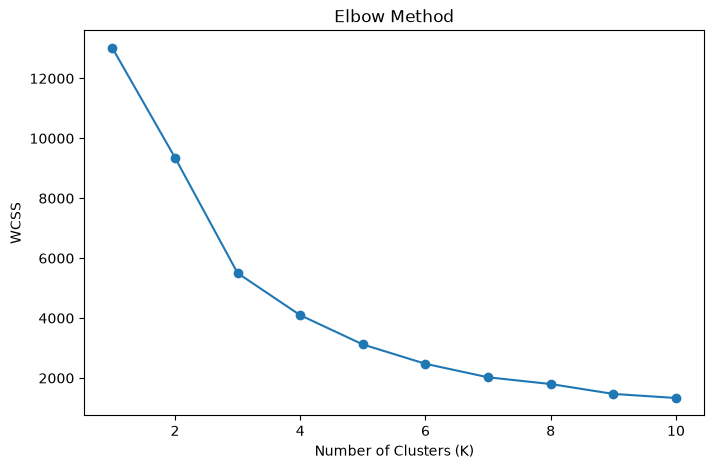

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.show()

## Observation

- The Elbow Method was used to determine the optimal number of customer clusters.
- As the number of clusters increased, the WCSS value decreased.
- The optimal value of K was selected at the point where the decrease in WCSS became less significant (the "elbow" of the graph).

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
kmeans.predict(rfm_scaled)
kmeans.fit_predict(rfm_scaled)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,3
12347.0,1,7,4310.00,0
12348.0,74,4,1797.24,0
12349.0,18,1,1757.55,0
12350.0,309,1,334.40,1


## Observation

- The K-Means algorithm successfully assigned each customer to a cluster.
- Each cluster represents a group of customers with similar purchasing behaviour.
- These cluster labels will be used for visualization and customer profiling.

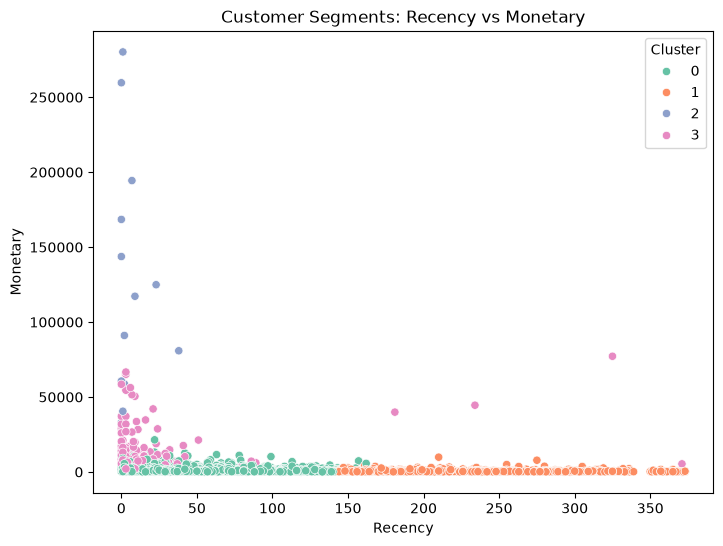

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

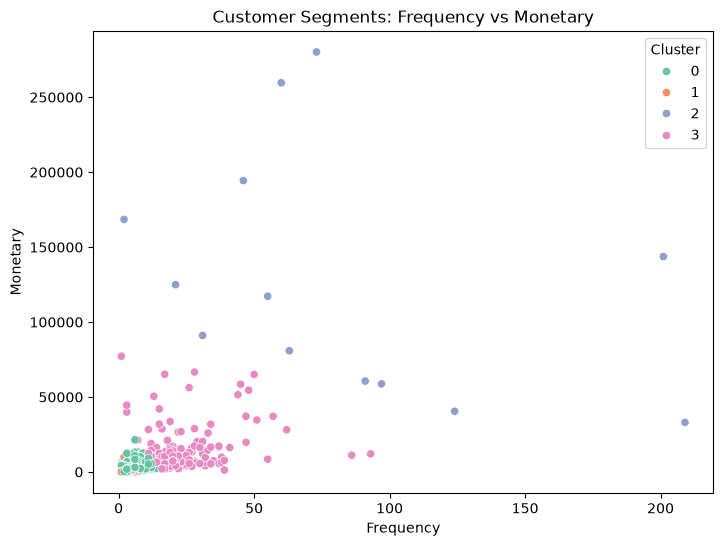

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

## Observation

- The scatter plots show how customers are grouped based on purchasing behaviour.
- Different colours represent different customer segments.
- Customers within the same cluster have similar Recency, Frequency, and Monetary characteristics.

In [ ]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

## Observation

- Cluster profiling shows the average purchasing behaviour of customers in each segment.
- Clusters with low Recency and high Frequency/Monetary values represent loyal and valuable customers.
- Clusters with high Recency and low Frequency indicate inactive or at-risk customers.

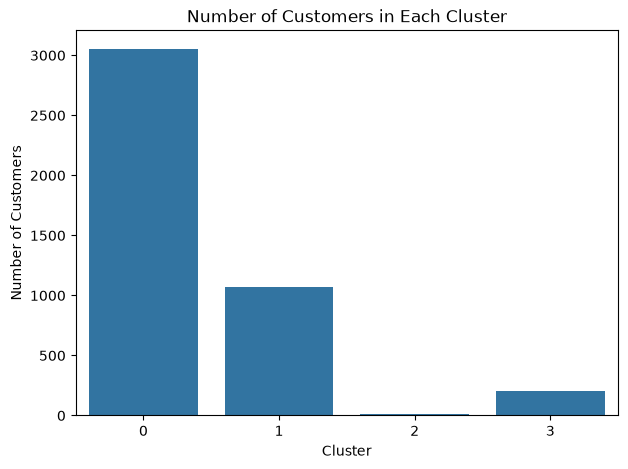

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=rfm,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

## Observation

- The bar chart shows the number of customers in each cluster.
- Some customer segments contain more customers than others.
- This information helps prioritize marketing efforts.

# Insights and Marketing Recommendations

### Cluster 0 – Loyal Customers

Characteristics

- Recent purchases
- Frequent buyers
- High spending

Recommendation

- Offer VIP membership.
- Provide loyalty rewards.
- Recommend premium products.

---

### Cluster 1 – At-Risk Customers

Characteristics

- Long time since last purchase.
- Low purchase frequency.

Recommendation

- Send discount coupons.
- Launch re-engagement email campaigns.

---

### Cluster 2 – Regular Customers

Characteristics

- Moderate purchase frequency.
- Average spending.

Recommendation

- Recommend related products.
- Offer bundle discounts.

---

### Cluster 3 – Low-Value Customers

Characteristics

- Rare purchases.
- Low spending.

Recommendation

- Use introductory offers.
- Encourage repeat purchases with limited-time promotions.

# Conclusion

This project applied K-Means clustering to segment customers based on Recency, Frequency, and Monetary (RFM) analysis.

The clustering process identified distinct customer groups with different purchasing behaviours.

These insights can help businesses:

- Improve customer retention.
- Increase customer lifetime value.
- Design personalized marketing campaigns.
- Optimize promotional strategies.